#### Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway

# Load the data
df = pd.read_csv('../data/raw/MachineLearningRating_v3.txt', sep='|')

# Derive KPI columns
df['HadClaim'] = df['TotalClaims'] > 0
df['ClaimFrequency'] = df['HadClaim'].astype(int)
df['ClaimSeverity'] = df['TotalClaims'] / df['HadClaim'].replace(0, np.nan)
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

print("✅ Data loaded and KPI columns created.")


C:\Users\bruht\AppData\Local\Temp\ipykernel_14988\3719383710.py:8: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/MachineLearningRating_v3.txt', sep='|')


✅ Data loaded and KPI columns created.


#### Hypothesis 1: Province Risk Differences

In [2]:
# Filter 2 major provinces for testing
provinces = ['Gauteng', 'Western Cape']
df_prov = df[df['Province'].isin(provinces)]

# t-test on Claim Frequency
t_stat_freq, p_val_freq = ttest_ind(
    df_prov[df_prov['Province'] == 'Gauteng']['ClaimFrequency'],
    df_prov[df_prov['Province'] == 'Western Cape']['ClaimFrequency'],
    equal_var=False
)

# t-test on Claim Severity
t_stat_sev, p_val_sev = ttest_ind(
    df_prov[df_prov['Province'] == 'Gauteng']['ClaimSeverity'].dropna(),
    df_prov[df_prov['Province'] == 'Western Cape']['ClaimSeverity'].dropna(),
    equal_var=False
)

print(f"Province Risk (Frequency) - p = {p_val_freq:.4f}")
print(f"Province Risk (Severity) - p = {p_val_sev:.4f}")


Province Risk (Frequency) - p = 0.0000
Province Risk (Severity) - p = nan


c:\Users\bruht\Documents\Kifiya\Week 3\Risk-Analytics-and-Predictive-Modeling\venv\Lib\site-packages\scipy\stats\_stats_py.py:6154: RuntimeWarning: invalid value encountered in scalar subtract
  d = mean1 - mean2
c:\Users\bruht\Documents\Kifiya\Week 3\Risk-Analytics-and-Predictive-Modeling\venv\Lib\site-packages\scipy\stats\_stats_py.py:6707: RuntimeWarning: invalid value encountered in scalar subtract
  estimate = m1 - m2


#### Hypothesis 2: Zip Code Risk Differences

In [3]:
# Choose 2 representative zip codes
zips = df['PostalCode'].value_counts().head(2).index
df_zip = df[df['PostalCode'].isin(zips)]

# t-tests on claim metrics
t_freq, p_freq = ttest_ind(
    df_zip[df_zip['PostalCode'] == zips[0]]['ClaimFrequency'],
    df_zip[df_zip['PostalCode'] == zips[1]]['ClaimFrequency']
)

t_sev, p_sev = ttest_ind(
    df_zip[df_zip['PostalCode'] == zips[0]]['ClaimSeverity'].dropna(),
    df_zip[df_zip['PostalCode'] == zips[1]]['ClaimSeverity'].dropna()
)

print(f"ZipCode Risk (Frequency) - p = {p_freq:.4f}")
print(f"ZipCode Risk (Severity) - p = {p_sev:.4f}")


ZipCode Risk (Frequency) - p = 0.0525
ZipCode Risk (Severity) - p = 0.6736


#### Hypothesis 3: Margin Difference Between Zip Codes

In [4]:
t_margin, p_margin = ttest_ind(
    df_zip[df_zip['PostalCode'] == zips[0]]['Margin'],
    df_zip[df_zip['PostalCode'] == zips[1]]['Margin']
)

print(f"ZipCode Margin Difference - p = {p_margin:.4f}")


ZipCode Margin Difference - p = 0.1959


#### Hypothesis 4: Gender Risk Differences

In [5]:
# Frequency
t_gender_freq, p_gender_freq = ttest_ind(
    df[df['Gender'] == 'Male']['ClaimFrequency'],
    df[df['Gender'] == 'Female']['ClaimFrequency']
)

# Severity
t_gender_sev, p_gender_sev = ttest_ind(
    df[df['Gender'] == 'Male']['ClaimSeverity'].dropna(),
    df[df['Gender'] == 'Female']['ClaimSeverity'].dropna()
)

print(f"Gender Risk (Frequency) - p = {p_gender_freq:.4f}")
print(f"Gender Risk (Severity) - p = {p_gender_sev:.4f}")


Gender Risk (Frequency) - p = 0.8405
Gender Risk (Severity) - p = 0.6760


#### Visualizations 

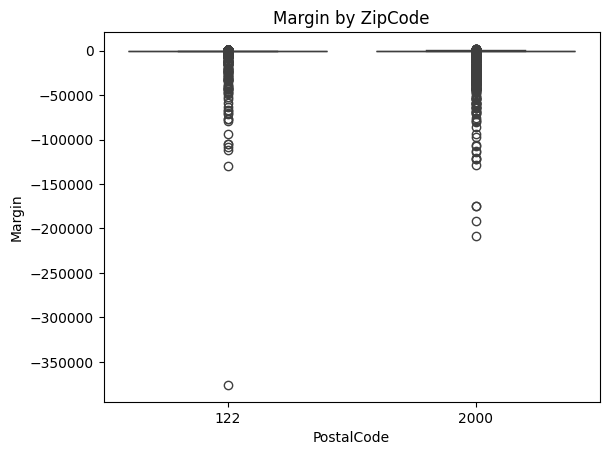

In [6]:
sns.boxplot(data=df_zip, x='PostalCode', y='Margin')
plt.title("Margin by ZipCode")
plt.show()
